<a href="https://colab.research.google.com/github/uniquegalaxycoder/Project/blob/main/Machine_Failure_Prediction_(Decision_Tree).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Problem Statement**

####**Business Context**
System failure is a common issue across the manufacturing industry, where a variety of machines and equipment are used. In most cases, it becomes important to be able to predict machine failures by analyzing system data and taking preventive measures to be able to tackle them. This is known as predictive maintenance and with the rising availability of data and computational resources, the use of such data-driven, proactive maintenance methods has resulted in several benefits like minimized downtime of the equipment, minimized cost associated with spares and supplies, etc.

AutoMobi Engineering Pvt. Ltd is an auto component manufacturing company. The manufacturing facility of AutoMobi consists of numerous products machined on several CNC (Computer Numerical Controlled) machines. In an attempt to transition to a data-driven maintenance process, the company had set up sensors in various locations to collect data regarding the various parameters involved in the manufacturing process. Initially, they want to try it in an injector nozzle manufacturing shop where they are manufacturing fuel injector nozzles for automobile engines using various manufacturing processes (like turning, drilling, etc). The company has been collecting data on an hourly basis from these sensors and aims to build ML-based solutions using the data to optimize cost, improve failure predictability, and minimize the downtime of equipment.

## **Objective**
AutoMobi has recently been encountering a problem with frequent equipment failure in the fuel injector nozzle manufacture unit, leading to disturbance in the manufacturing process. They have reached out to the Data Science team for a solution and shared data for the past three months. As a member of the Data Science team, you are tasked with analyzing the data and developing a Machine Learning model to detect potential machine failures, determine the most influencing factors on machine health, and provide recommendations for cost optimization to the management.

###**Data Description**
The data contains the different attributes of machines and health. The detailed data dictionary is given below.

**Data Dictionary**

* **UDI:** Unique identifier ranging from 1 to 10000
* **Type:** The type of product consisting of low(60% of all products), medium(30%), and high(10%) quality corresponding to L, M, and H
* **Air temperature:** Ambient temperature (in the machine shop) measured in Kelvin
* **Process Temperature:** Tool tip temperature measured in Kelvin
* **Rotational Speed:** Rotational speed of the machine spindle measured in revolutions per minute (rpm)
* **Torque:** Torque acting on the machine spindle measured in Newton meter (Nm)
* **Tool wear:** Tool wear measured in micrometers (During the manufacturing process, continuous rubbing of the tool on the workpiece leads to the wearing of the tool material. The tool wear is measured as the amount of wear on the cutting face of the tool measured in micrometers)
* **Failure:** 0-No failure, 1-Failure

In [491]:
# Importing all the libraries
# to load data
import pandas as pd
import numpy as np
import math
# to visualize data
import seaborn as sns
import matplotlib.pyplot as plt

# to maintain the number precision
pd.options.display.float_format = '{:.5f}'.format

# to ignore warnings
import warnings
warnings.filterwarnings('ignore')

# to split data into training & testing
from sklearn.model_selection import train_test_split, cross_val_score

# to build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree


# to tune different models
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# to perform statistical analysis
import scipy.stats as stats

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    classification_report
)

# displaying max column
pd.set_option('display.max_columns', None)

In [492]:
# connecting google drive to colab
from google.colab import drive
drive.mount('/content/drive', force_remount= True)

Mounted at /content/drive


In [493]:
# Load data
try :
  data = pd.read_csv('/content/drive/My Drive/Python 2026/practice csv files/machine_failure_data.csv')
  print(" 🚀 Data loaded successfuly")
except Exception as a :
  print(a)

 🚀 Data loaded successfuly


In [494]:
# making a copy of original dataset
df = data.copy()

In [495]:
# checking the first 5 rows
df.head()

,UDI,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure
0,1,M,298.10000,323.74074,1551,42.80000,0,0
1,2,L,298.20000,324.11111,1408,46.30000,3,0
2,3,L,298.10000,323.37037,1498,49.40000,5,0
3,4,L,298.20000,323.74074,1433,39.50000,7,0
4,5,L,298.20000,324.11111,1408,40.00000,9,0


In [496]:
# checking last 5 rows
df.tail()

,UDI,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure
9995,9996,M,298.80000,323.00000,1604,29.50000,14,0
9996,9997,H,298.90000,323.00000,1632,31.80000,17,0
9997,9998,M,299.00000,323.74074,1645,33.40000,22,0
9998,9999,H,299.00000,324.11111,1408,48.50000,25,0
9999,10000,M,299.00000,324.11111,1500,40.20000,30,0


In [497]:
# checking the shape of data
rows, columns = df.shape
print(f"Total Rows : {rows}")
print(f"Total no. of Columns : {columns}")

Total Rows : 10000
Total no. of Columns : 8


In [498]:
# checking the dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   UDI                  10000 non-null  int64  
 1   Type                 10000 non-null  object 
 2   Air temperature      10000 non-null  float64
 3   Process temperature  10000 non-null  float64
 4   Rotational speed     10000 non-null  int64  
 5   Torque               10000 non-null  float64
 6   Tool wear            10000 non-null  int64  
 7   Failure              10000 non-null  int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 625.1+ KB


Total 8 rows is there, out of that 1 is categorical & remaining has numercial

In [499]:
df.isnull().sum()

,0
UDI,0
Type,0
Air temperature,0
Process temperature,0
Rotational speed,0
Torque,0
Tool wear,0
Failure,0


There is no null values are present in dataset

In [500]:
df.duplicated().sum()

np.int64(0)

There is a no duplicates in data

In [501]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.00000,5000.50000,2886.89568,1.00000,2500.75000,5000.50000,7500.25000,10000.00000
Air temperature,10000.00000,300.00493,2.00026,295.30000,298.30000,300.10000,301.50000,304.50000
Process temperature,10000.00000,328.94652,5.49531,313.00000,324.48148,329.29630,333.00000,343.00000
Rotational speed,10000.00000,1538.77610,179.28410,1168.00000,1423.00000,1503.00000,1612.00000,2886.00000
Torque,10000.00000,39.98691,9.96893,3.80000,33.20000,40.10000,46.80000,76.60000
Tool wear,10000.00000,107.95100,63.65415,0.00000,53.00000,108.00000,162.00000,253.00000
Failure,10000.00000,0.03390,0.18098,0.00000,0.00000,0.00000,0.00000,1.00000


In [502]:
df.describe(include = ['object','category']).T

,count,unique,top,freq
Type,10000,3,L,6000


In [503]:
# checking some categorical columns value counts & target column value counts
features = df.iloc[:,[1,-1]].columns.tolist()

for i in features:
  a = df[i].value_counts()
  print(a)
  print("------------------------------------")

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64
------------------------------------
Failure
0    9661
1     339
Name: count, dtype: int64
------------------------------------


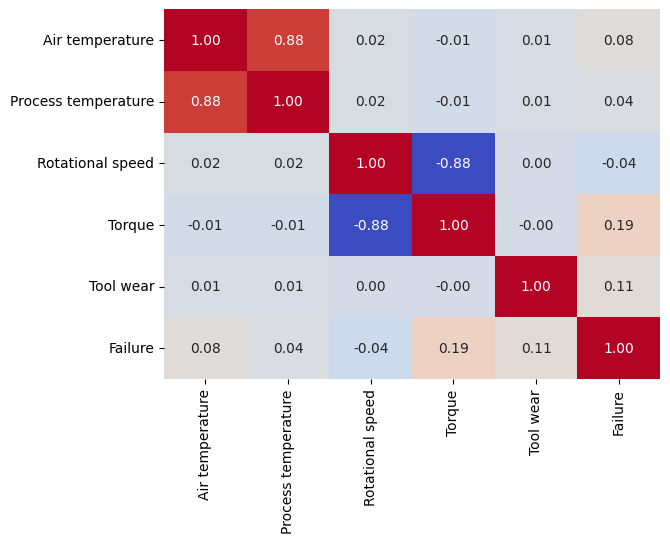

In [504]:
# checking the correlation between the features
sns.heatmap(df.iloc[:,1:].select_dtypes(include = ['number']).corr(), annot= True, cbar = False, fmt='0.2f', cmap = 'coolwarm')
plt.show()

* Torque Up, Speed Down. both are negative correlated with each other, like if you increased Torque (Load) speed will be decreased or vise versa.
* Air Tempreature, Process Tempreature. highly Positive correlated with each other, like Air temperature is high then Process temprature also increased.
* Torque, Failure. are low corelated with each other, like Torque increased may be tool Failure will occure.
* Tool Wear & Failure. both are positive correlated with each other. Tool wearing cuases the tool failure.

## **Data Pre-Processing**

In [505]:
# splitting the data into train & test
X = df.iloc[: , 1:-1]
y = df.iloc[: , [-1]]

In [506]:
X_dummies = pd.get_dummies(
    X,
    columns = ['Type'],
    drop_first=True,
    dtype = float
)
X_dummies.head()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Type_L,Type_M
0,298.10000,323.74074,1551,42.80000,0,0.00000,1.00000
1,298.20000,324.11111,1408,46.30000,3,1.00000,0.00000
2,298.10000,323.37037,1498,49.40000,5,1.00000,0.00000
3,298.20000,323.74074,1433,39.50000,7,1.00000,0.00000
4,298.20000,324.11111,1408,40.00000,9,1.00000,0.00000


In [507]:
# splitting the data inot trian & test
X_train, X_test, y_train, y_test = train_test_split(
    X_dummies,
    y,
    test_size = 0.3,
    random_state = 1
)

In [508]:
# checking the train & test dataset splitting %
print(f"Data % on Train : \n{y_train.value_counts(normalize=True)}\n")
print(f"Data & on Test : \n{y_test.value_counts(normalize=True)}")

Data % on Train : 
Failure
0         0.96629
1         0.03371
Name: proportion, dtype: float64

Data & on Test : 
Failure
0         0.96567
1         0.03433
Name: proportion, dtype: float64


## **Model Building**

In [509]:
# confusion matrics function

try :
  # ploting a confusion matrics
  def plot_confusion_matrics(model, predictor, target):

    # Predict the target values using the provided model and predictors
    y_pred = model.predict(predictor)

    # Compute the confusion matrix compairing the true target values with the predicted values
    cm = confusion_matrix(target, y_pred)

    TN = cm[0,0]
    FP = cm[0,1]
    FN = cm[1,0]
    TP = cm[1,1]

    cm_df = pd.DataFrame({
        "True Negative" : TN,
        "False Positive" : FP,
        "False Negative" : FN,
        "True Positive" : TP
    }, index = [0]).reset_index(drop=True)

    # create a labels for each cell in the confusion matrix with both count and percentage
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format( item / cm.flatten().sum()) for item in cm.flatten()]
        ]
    ).reshape(2, 2)

    plt.figure(figsize = (4,3))

    sns.heatmap(cm, annot = labels, cmap = 'Spectral', fmt = "")

    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")

    return cm_df

  print("Function defined")
except Exception as e :
  print(f"Model Not defined {e}")

Function defined


In [510]:
## Model Performance Evaluation

# definfing a function to compute different matrics to check performance of a classification model building
try :
  def model_performance_classification(model, preictors, target):
    # predicting independent variables
    y_pred = model.predict(preictors)

    # to compute accuracy
    acc_score = accuracy_score(target, y_pred)
    # to compute recall
    recall = recall_score(target, y_pred)
    # to compute precision
    precision = precision_score(target, y_pred)
    # to compute f1 score
    f1 = f1_score(target, y_pred)

    # creating a df for this matrics

    df_pred = pd.DataFrame({
        "Accuracy": acc_score,
        "Recall" : recall,
        "Precision" : precision,
        "F1" : f1
    }, index = [0])

    return df_pred
  print("Function Defined")
except Exception as r :
  print(f"FUnction not defined, {r}")

Function Defined


In [511]:
def classification_report_matrics(model, predicator, target):
  # prediction variable
  pred = model.predict(predicator)

  # confusion matrics
  cm = confusion_matrix(target, pred)
  error_rate = (cm[1,0]+ cm[0,1]) / (cm[0,0] + cm[0,1] + cm[1,0] + cm[1,1])

  # evaluation matrics
  acc = accuracy_score(target, pred)
  prec = precision_score(target, pred)
  recal = recall_score(target, pred)
  f1 = f1_score(target, pred)

  # keeping all matrics in one single df
  evaluation_df = pd.DataFrame({
      "Accuracy" : acc,
      "Precision" : prec,
      "Recall" : recal,
      "F1-Score" : f1,
      "Error Rate" : error_rate
  }, index = [0])

  return evaluation_df

### **Decision Tree with Default parameter**

In [512]:
# defining the decision tree
dtree1 = DecisionTreeClassifier(random_state = 1)

In [513]:
# fitting Train & test data into model
dtree1.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

,True Negative,False Positive,False Negative,True Positive
0,6764,0,0,236


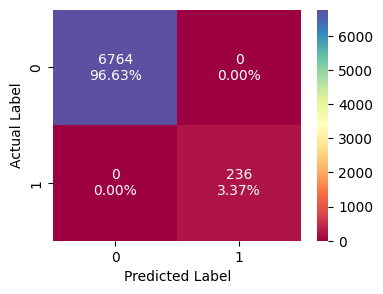

In [514]:
# plotting the confusion matrics for train data
plot_confusion_matrics(dtree1, X_train, y_train)

In [515]:
# Model performance report
default_dt_model_evaluation_train = classification_report_matrics(dtree1, X_train, y_train)
default_dt_model_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,1.00000,1.00000,1.00000,1.00000,0.00000


,True Negative,False Positive,False Negative,True Positive
0,2852,45,28,75


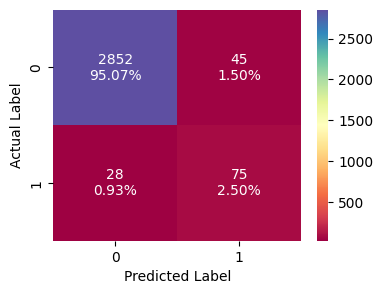

In [516]:
# confudsion matrics for test data
plot_confusion_matrics(dtree1, X_test, y_test)

In [517]:
default_dt_model_evaluation_test = classification_report_matrics(dtree1, X_test, y_test)
default_dt_model_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.97567,0.62500,0.72816,0.67265,0.02433


In [518]:
print("Model Evaluation on train dataset")
print(f"{default_dt_model_evaluation_train}\n")
print("Model Evaluation on Test dataset")
print(default_dt_model_evaluation_test)

Model Evaluation on train dataset
   Accuracy  Precision  Recall  F1-Score  Error Rate
0   1.00000    1.00000 1.00000   1.00000     0.00000

Model Evaluation on Test dataset
   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.97567    0.62500 0.72816   0.67265     0.02433


On Default Decision Tree our model, Accuracy on Train data is around 1.00 & on Test data model accuracy is around 0.97 which is good. But recall on train data is 1.00 & recall on test data 0.72 is clearly indecating the model get overfitting.

## **Decision Tree with class_weight**

In [561]:
# decision tree initialize with clas weight parameter
dtree_class_weight = DecisionTreeClassifier(random_state = 1, class_weight = 'balanced')

In [562]:
# fittng the data into model
dtree_class_weight.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

,True Negative,False Positive,False Negative,True Positive
0,6764,0,0,236


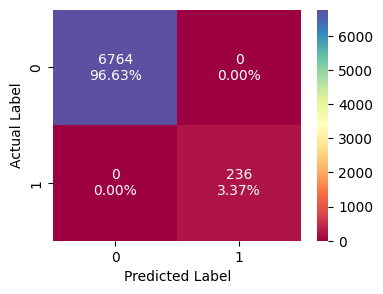

In [563]:
# plotting the confusion matrics
plot_confusion_matrics(dtree_class_weight, X_train, y_train)

In [564]:
classweight_dt_model_evaluation_train = classification_report_matrics(dtree_class_weight, X_train, y_train)
classweight_dt_model_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,1.00000,1.00000,1.00000,1.00000,0.00000


,True Negative,False Positive,False Negative,True Positive
0,2868,29,40,63


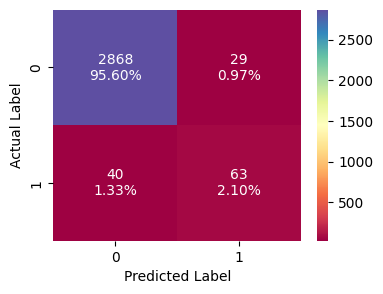

In [566]:
plot_confusion_matrics(dtree_class_weight, X_test, y_test)

In [565]:
classweight_dt_model_evaluation_test = classification_report_matrics(dtree_class_weight, X_test, y_test)
classweight_dt_model_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.97700,0.68478,0.61165,0.64615,0.02300


In [567]:
print("Model Evaluation on train dataset after considering class_weight\n")
print(f"{classweight_dt_model_evaluation_train}\n")
print("Model Evaluation on Test dataset after considering class_weight\n")
print(classweight_dt_model_evaluation_test)

Model Evaluation on train dataset after considering class_weight

   Accuracy  Precision  Recall  F1-Score  Error Rate
0   1.00000    1.00000 1.00000   1.00000     0.00000

Model Evaluation on Test dataset after considering class_weight

   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.97700    0.68478 0.61165   0.64615     0.02300


* After adding a class_weight parameter alon in model, model got overfitted.

## **Pre-Pruned Decision Tree**

In [519]:
# using GridSearchCV we finding the best parameters for model
param_grid = {
    "max_depth" : np.arange(2,7,1),
    "min_samples_split" : np.arange(10, 70, 15),
    "min_samples_leaf" : np.arange(50, 250, 25),
    # "max_features" : [None, 'sqrt', 'log2']
}

In [520]:
grid_dtree_2 = GridSearchCV(
    DecisionTreeClassifier(random_state = 1, class_weight='balanced'),
    param_grid = param_grid,
    cv = 5,
    scoring = 'f1',
    n_jobs=-1
)

In [521]:
# fitting the train data into decision tree 2
grid_dtree_2.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=1),
             n_jobs=-1,
             param_grid={'max_depth': array([2, 3, 4, 5, 6]),
                         'min_samples_leaf': array([ 50,  75, 100, 125, 150, 175, 200, 225]),
                         'min_samples_split': array([10, 25, 40, 55])},
             scoring='f1')

In [522]:
# get best parameters
print(grid_dtree_2.best_params_)
print()
print(grid_dtree_2.best_estimator_)

{'max_depth': np.int64(5), 'min_samples_leaf': np.int64(50), 'min_samples_split': np.int64(10)}

DecisionTreeClassifier(class_weight='balanced', max_depth=np.int64(5),
                       min_samples_leaf=np.int64(50),
                       min_samples_split=np.int64(10), random_state=1)


In [523]:
# assigning the model into new variable
dtree2 = grid_dtree_2.best_estimator_

,True Negative,False Positive,False Negative,True Positive
0,6081,683,8,228


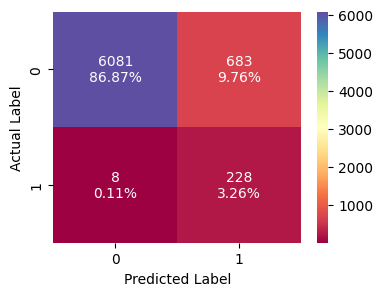

In [524]:
# plotting the confusion matrics on train data
plot_confusion_matrics(dtree2, X_train, y_train)

In [525]:
# model performance Evaluation on train data
pre_prun_dt_model_evaluation_train = classification_report_matrics(dtree2, X_train, y_train)
pre_prun_dt_model_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.90129,0.25027,0.96610,0.39756,0.09871


,True Negative,False Positive,False Negative,True Positive
0,2622,275,1,102


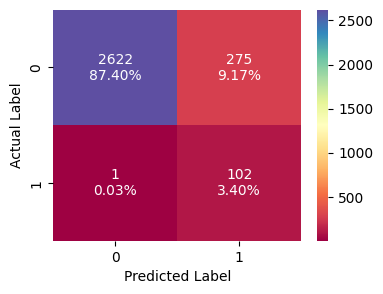

In [526]:
# plotting confusion matrics on test data
plot_confusion_matrics(dtree2, X_test, y_test)

In [527]:
# model performance evaluation on test data
pre_prun_dt_model_evaluation_test = classification_report_matrics(dtree2, X_test, y_test)
pre_prun_dt_model_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.90800,0.27056,0.99029,0.42500,0.09200


Model getting genralized result on Train & test data. recall rate around 0.96 on train data & 0.99 on test data. on accuracy in both the cases around 0.90

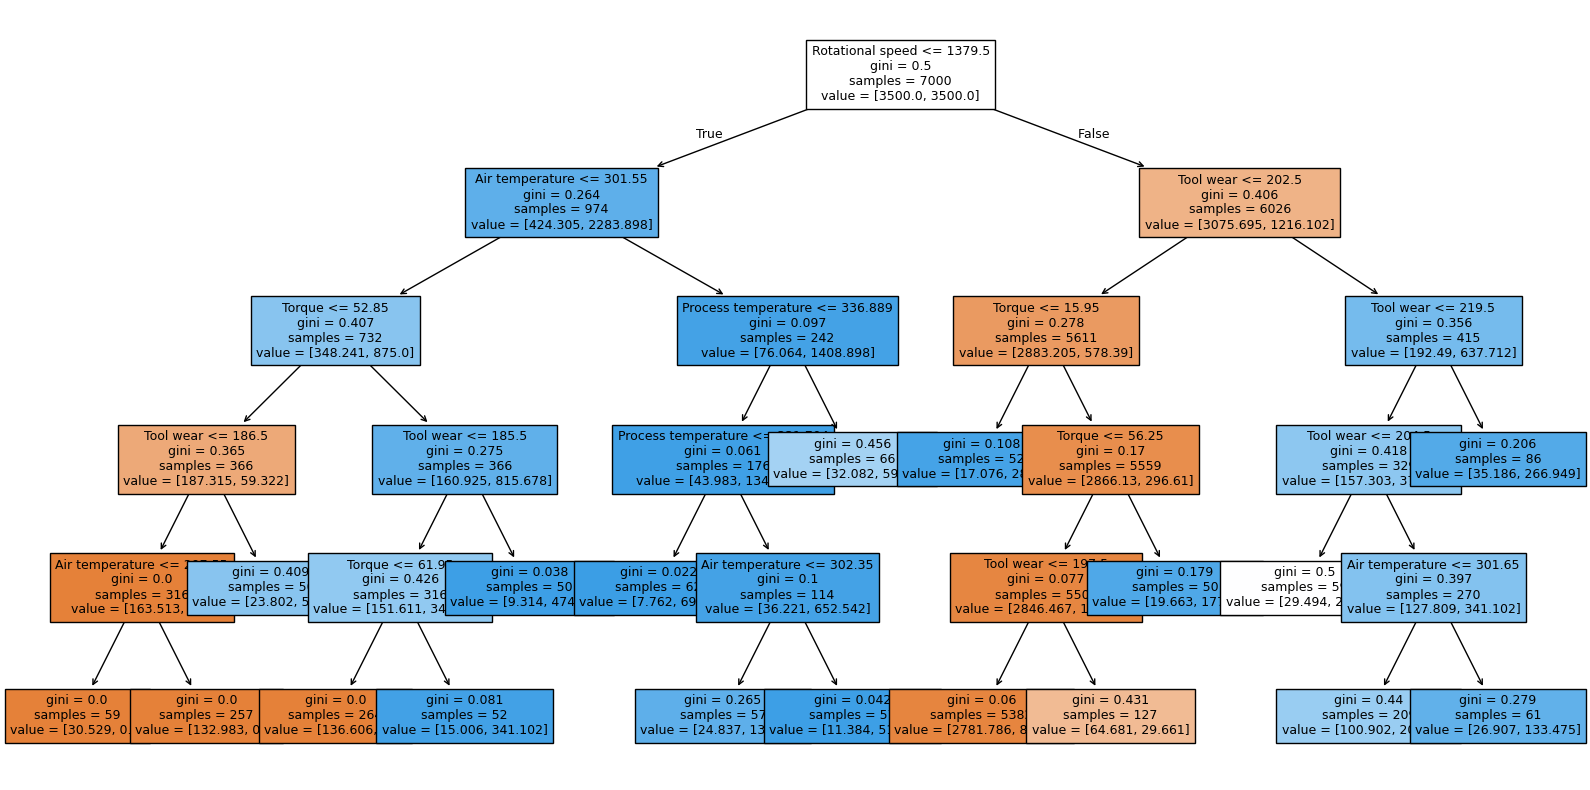

In [528]:
# visualization of pre-pruned Decision tree

feature_names = X_dummies.columns.tolist()
plt.figure(figsize = (20, 10))
trees = tree.plot_tree(
    dtree2,
    feature_names = feature_names,
    filled = True,
    fontsize = 9,
)

In [529]:
# Text report showing the rules of a decision tree -
feature_names_2 = X_dummies.columns.tolist()
print(tree.export_text(dtree2, feature_names=feature_names_2, show_weights=True))


|--- Rotational speed <= 1379.50
|   |--- Air temperature <= 301.55
|   |   |--- Torque <= 52.85
|   |   |   |--- Tool wear <= 186.50
|   |   |   |   |--- Air temperature <= 297.55
|   |   |   |   |   |--- weights: [30.53, 0.00] class: 0
|   |   |   |   |--- Air temperature >  297.55
|   |   |   |   |   |--- weights: [132.98, 0.00] class: 0
|   |   |   |--- Tool wear >  186.50
|   |   |   |   |--- weights: [23.80, 59.32] class: 1
|   |   |--- Torque >  52.85
|   |   |   |--- Tool wear <= 185.50
|   |   |   |   |--- Torque <= 61.95
|   |   |   |   |   |--- weights: [136.61, 0.00] class: 0
|   |   |   |   |--- Torque >  61.95
|   |   |   |   |   |--- weights: [15.01, 341.10] class: 1
|   |   |   |--- Tool wear >  185.50
|   |   |   |   |--- weights: [9.31, 474.58] class: 1
|   |--- Air temperature >  301.55
|   |   |--- Process temperature <= 336.89
|   |   |   |--- Process temperature <= 331.70
|   |   |   |   |--- weights: [7.76, 697.03] class: 1
|   |   |   |--- Process temperature > 

In [530]:
# feature importance
feature_importance = pd.DataFrame({
    "Features" : X_dummies.columns,
    "Importance" : dtree2.feature_importances_.round(2)
}).sort_values(by = ['Importance'], ascending = False).reset_index(drop=True)

print(feature_importance)

              Features  Importance
0     Rotational speed     0.38000
1               Torque     0.36000
2            Tool wear     0.22000
3      Air temperature     0.03000
4  Process temperature     0.01000
5               Type_L     0.00000
6               Type_M     0.00000


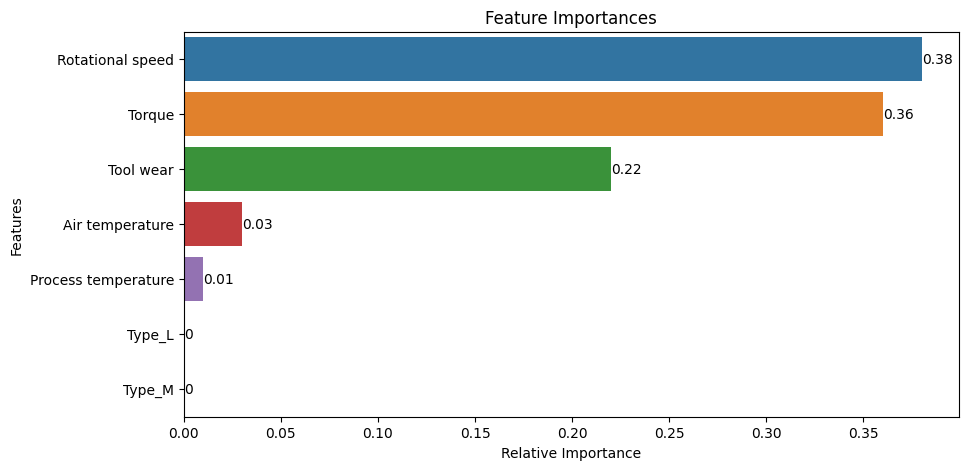

In [531]:
# plotting this above importance values in graph
plt.figure(figsize = (10,5))
plt.title("Feature Importances")
plot_1 = sns.barplot(feature_importance, x = 'Importance', y = 'Features', hue = 'Features')
plt.xlabel("Relative Importance")
plt.ylabel("Features")

for value in plot_1.containers:
  plot_1.bar_label(value)

plt.show()

In the pre-pruned decision tree, Rotation Speed, Torque, Tool wear are the most important features.

##**Post-Pruned Decision Tree**

In [532]:
# train full tree

clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [533]:
pd.DataFrame(path)

,ccp_alphas,impurities
0,0.00000,-0.00000
1,0.00000,-0.00000
2,0.00000,-0.00000
3,0.00000,-0.00000
4,0.00000,-0.00000
...,...,...
90,0.01578,0.18187
91,0.04268,0.22456
92,0.05757,0.28212
93,0.06912,0.35124


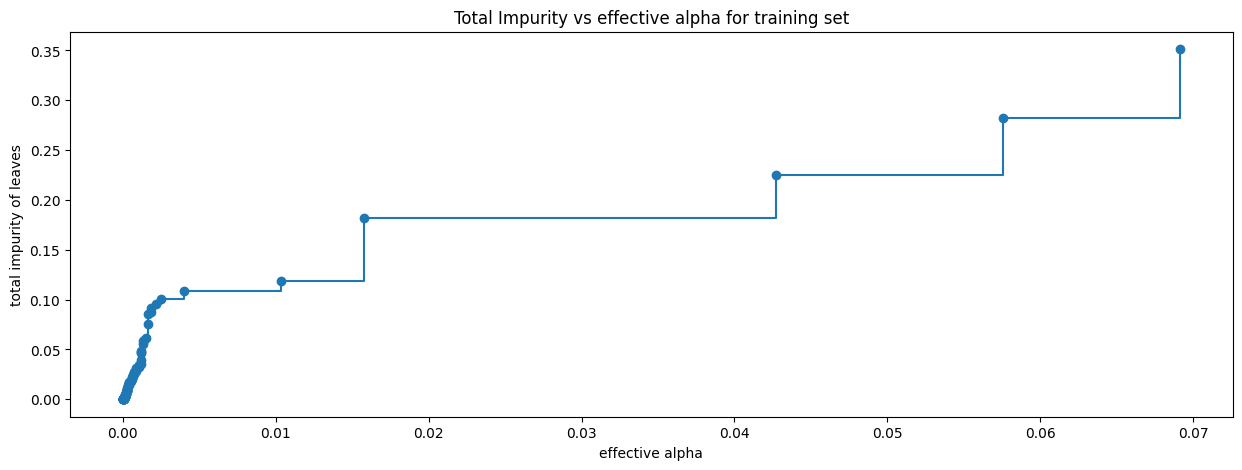

In [534]:
fig, ax = plt.subplots(figsize = (15, 5))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker = "o", drawstyle = "steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")
plt.show()

In [535]:
clfs = []

for ccp_alpha in ccp_alphas :
  clf = DecisionTreeClassifier(random_state = 1, ccp_alpha = ccp_alpha, class_weight = "balanced")
  clf.fit(X_train, y_train)
  clfs.append(clf)
print(f"Number of nodes in the last tree is : {clfs[-1].tree_.node_count} with ccp_alpha {ccp_alphas[-1]}")

Number of nodes in the last tree is : 1 with ccp_alpha 0.14875976077076158


In [536]:
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

In [537]:
recall_train = []

for clf in clfs:
  recall = recall_score(y_train, clf.predict(X_train))
  recall_train.append(recall)

In [538]:
recall_test = []

for clf in clfs:
  recall = recall_score(y_test, clf.predict(X_test))
  recall_test.append(recall)


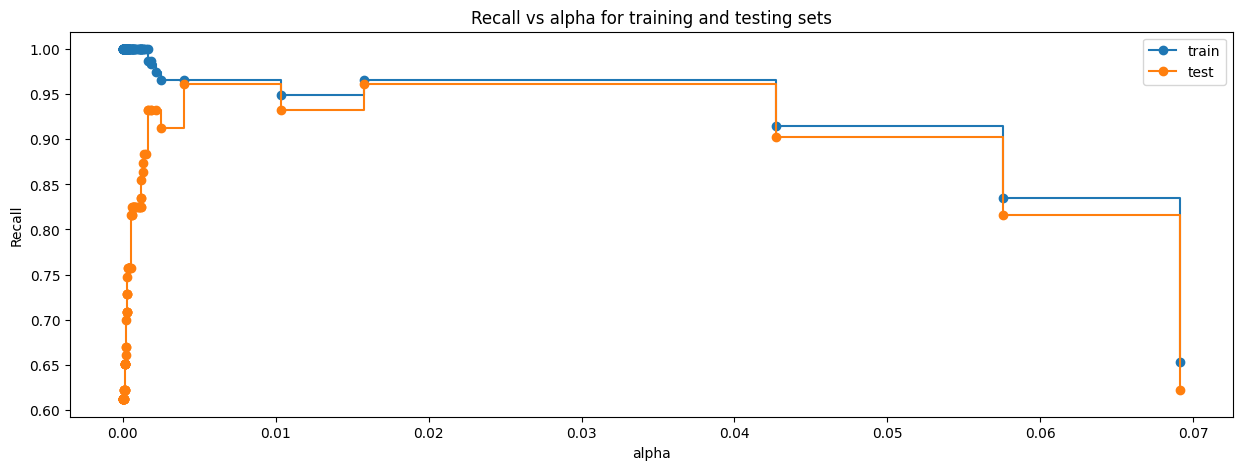

In [539]:
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [540]:
best_idx = np.argmax(recall_test)
best_alpha = ccp_alphas[best_idx]
print(f"Best Alpha Value : {best_alpha}")

Best Alpha Value : 0.004008680486241742


In [541]:
# creating the model where we get highest train and test recall

dtree3 = DecisionTreeClassifier(random_state =42, ccp_alpha = best_alpha, class_weight = 'balanced')
print(dtree3)

DecisionTreeClassifier(ccp_alpha=np.float64(0.004008680486241742),
                       class_weight='balanced', random_state=42)


In [542]:
dtree3.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.004008680486241742),
                       class_weight='balanced', random_state=42)

,True Negative,False Positive,False Negative,True Positive
0,6211,553,8,228


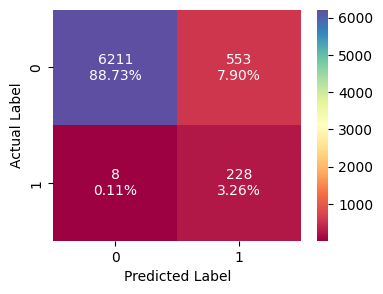

In [543]:
plot_confusion_matrics(dtree3, X_train, y_train)

In [544]:
post_prun_dt_model_evaluation_train = classification_report_matrics(dtree3, X_train, y_train)
post_prun_dt_model_evaluation_train

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.91986,0.29193,0.96610,0.44838,0.08014


,True Negative,False Positive,False Negative,True Positive
0,2668,229,9,94


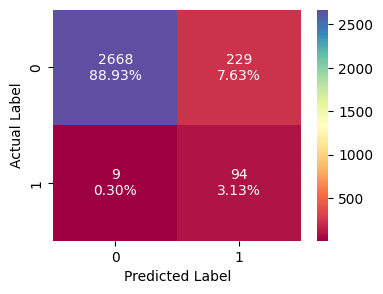

In [545]:
plot_confusion_matrics(dtree3, X_test, y_test)

In [546]:
post_prun_dt_model_evaluation_test = classification_report_matrics(dtree3, X_test, y_test)
post_prun_dt_model_evaluation_test

,Accuracy,Precision,Recall,F1-Score,Error Rate
0,0.92067,0.29102,0.91262,0.44131,0.07933


In [547]:
print("Post Prun Decision Tree Classifier Evaluation on Train\n")
print(f"{post_prun_dt_model_evaluation_train}\n")
print("Post Prun Decision Tree Classifier Evaluation on Test\n")
print(f"{post_prun_dt_model_evaluation_test}\n")

Post Prun Decision Tree Classifier Evaluation on Train

   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.91986    0.29193 0.96610   0.44838     0.08014

Post Prun Decision Tree Classifier Evaluation on Test

   Accuracy  Precision  Recall  F1-Score  Error Rate
0   0.92067    0.29102 0.91262   0.44131     0.07933



* After Post-pruning the model, our accuracy in both the train & test is around 0.91.
* Precision is around 0.29 in both the train & test model. with recall 0.96 on train 0.92 on test. which is indicating Genralized Model on unseen data.

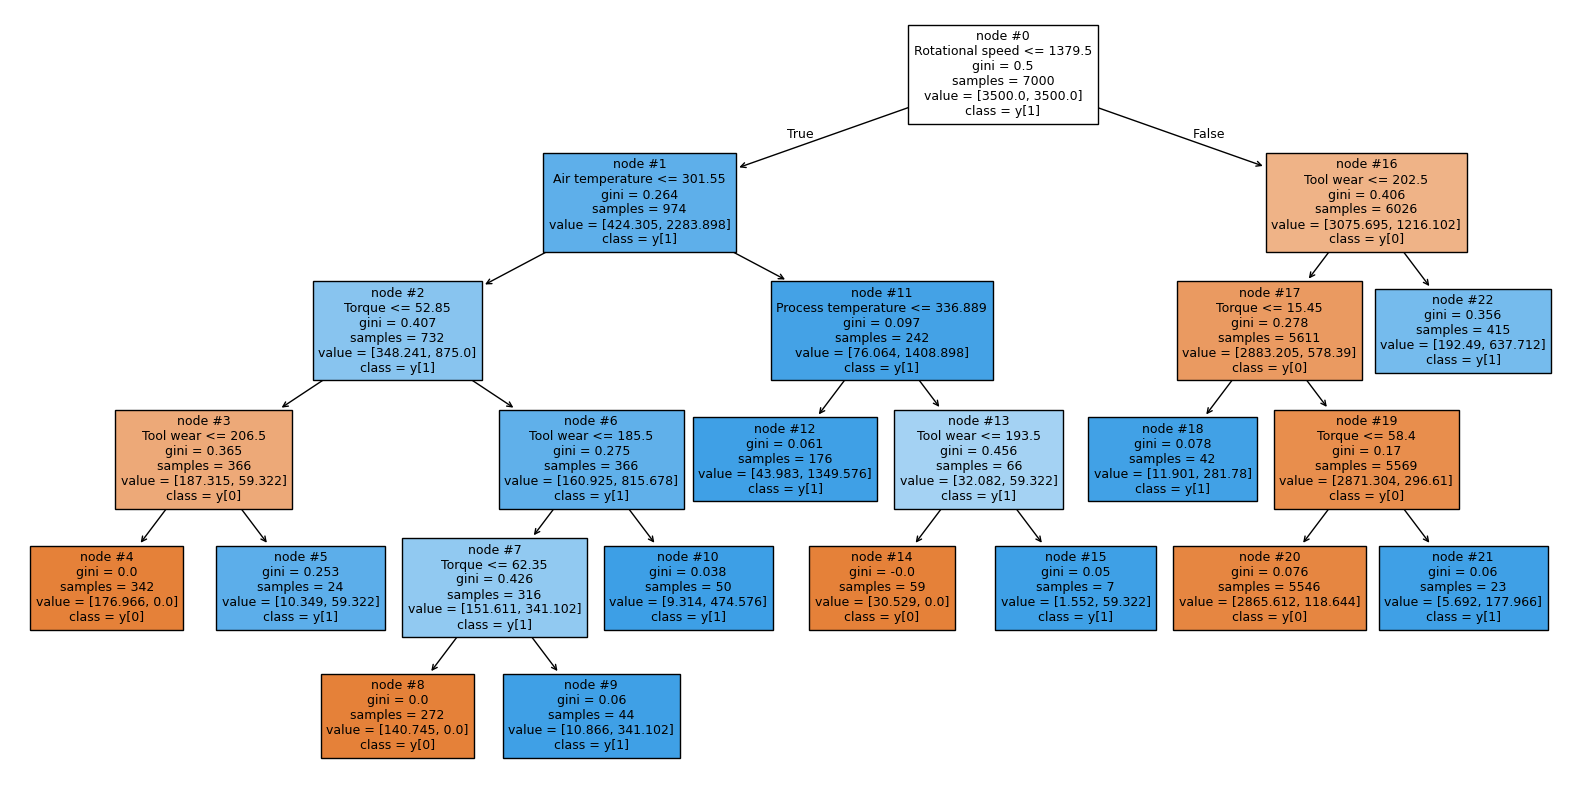

In [554]:
# plotting the tree
feature_names = X_dummies.columns.tolist()

plt.figure(figsize = (20, 10))
plot_2 = tree.plot_tree(
    dtree3,
    feature_names = feature_names,
    filled = True,
    node_ids = True,
    fontsize = 9,
    class_names = True
)

In [553]:
# test tree
feature_names = X_dummies.columns.tolist()

print(tree.export_text(dtree3, feature_names=feature_names, show_weights=True ))

|--- Rotational speed <= 1379.50
|   |--- Air temperature <= 301.55
|   |   |--- Torque <= 52.85
|   |   |   |--- Tool wear <= 206.50
|   |   |   |   |--- weights: [176.97, 0.00] class: 0
|   |   |   |--- Tool wear >  206.50
|   |   |   |   |--- weights: [10.35, 59.32] class: 1
|   |   |--- Torque >  52.85
|   |   |   |--- Tool wear <= 185.50
|   |   |   |   |--- Torque <= 62.35
|   |   |   |   |   |--- weights: [140.75, 0.00] class: 0
|   |   |   |   |--- Torque >  62.35
|   |   |   |   |   |--- weights: [10.87, 341.10] class: 1
|   |   |   |--- Tool wear >  185.50
|   |   |   |   |--- weights: [9.31, 474.58] class: 1
|   |--- Air temperature >  301.55
|   |   |--- Process temperature <= 336.89
|   |   |   |--- weights: [43.98, 1349.58] class: 1
|   |   |--- Process temperature >  336.89
|   |   |   |--- Tool wear <= 193.50
|   |   |   |   |--- weights: [30.53, 0.00] class: 0
|   |   |   |--- Tool wear >  193.50
|   |   |   |   |--- weights: [1.55, 59.32] class: 1
|--- Rotational spee

In [558]:
# feature importance

feature_importance = pd.DataFrame({
    "Feature" : X_dummies.columns,
    "Importance" : dtree3.feature_importances_.round(3)
}).sort_values(by = ["Importance"], ascending = False).reset_index(drop=True)

print(feature_importance)

               Feature  Importance
0     Rotational speed     0.37200
1               Torque     0.36800
2            Tool wear     0.22700
3      Air temperature     0.02600
4  Process temperature     0.00600
5               Type_L     0.00000
6               Type_M     0.00000


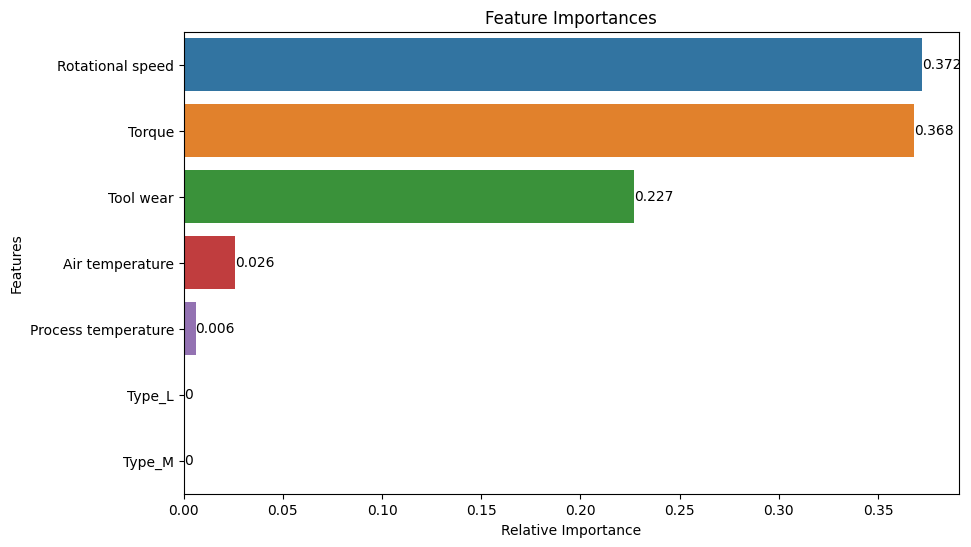

In [560]:
# plotting this above importance values in graph
plt.figure(figsize = (10,6))
plt.title("Feature Importances")
plot_3 = sns.barplot(feature_importance, x = 'Importance', y = 'Feature', hue = 'Feature')
plt.xlabel("Relative Importance")
plt.ylabel("Features")

for value in plot_3.containers:
  plot_3.bar_label(value)

plt.show()

as we can see, in feature importance Rotation speed, Torque, Tool Wear & air temprature this 4 attributes are very important, to predict tool will get failure or not.

## **Comparison of Models and Final Model Selection**

In [571]:
model_train_compare_df = pd.concat(
    [
        default_dt_model_evaluation_train.T,
        classweight_dt_model_evaluation_train.T,
        pre_prun_dt_model_evaluation_train.T,
        post_prun_dt_model_evaluation_train.T
    ],
    axis=1,
)

model_train_compare_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]

model_train_compare_df

,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,1.00000,1.00000,0.90129,0.91986
Precision,1.00000,1.00000,0.25027,0.29193
Recall,1.00000,1.00000,0.96610,0.96610
F1-Score,1.00000,1.00000,0.39756,0.44838
Error Rate,0.00000,0.00000,0.09871,0.08014


In [572]:
model_test_compare_df = pd.concat(
    [
        default_dt_model_evaluation_test.T,
        classweight_dt_model_evaluation_test.T,
        pre_prun_dt_model_evaluation_test.T,
        post_prun_dt_model_evaluation_test.T
    ],
    axis=1,
)

model_test_compare_df.columns = [
    "Decision Tree (sklearn default)",
    "Decision Tree with class_weight",
    "Decision Tree (Pre-Pruning)",
    "Decision Tree (Post-Pruning)",
]

model_test_compare_df

,Decision Tree (sklearn default),Decision Tree with class_weight,Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.97567,0.97700,0.90800,0.92067
Precision,0.62500,0.68478,0.27056,0.29102
Recall,0.72816,0.61165,0.99029,0.91262
F1-Score,0.67265,0.64615,0.42500,0.44131
Error Rate,0.02433,0.02300,0.09200,0.07933


- After post-pruning our model accuracy is around 0.92 on test & 0.91. with recall rate on Test 0.91 & 0.96 on Train.

- Pre-pruning Decision Tree model is giving the highst recall rate on Test. (0.99)

- So, we considering **Decision Tree (Pre-Pruned)** as a Final Model.


## **Conclusions and Recommendations**

* The model built can be used to predict if a machine is going to fail or not and can correctly identify 99% of the machine failures

* Rotational speed, torque and tool wear are the most important variables in predicting whether a machine will fail or not

* From the decision tree, it has been observed that if the rotational speed is less than or equal to 1379.50, the air temperature is less than or equal to 301.55, the torque is less than or equal to 52.85 and the tool wear is greater than 206.50, then the machine is most likey to fail.

* As the variable used vary with the type of operation (turning, drilling, etc.) being performed, the company can look to build separate models for each different type of operation